---
title: Pronóstico de Series Temporales con LSTM y GRU en PyTorch
subject: Aprendizaje Profundo
subtitle: 
short_title: Series Temporales con LSTM y GRU
authors:
  - name: Jorge Anais
    orcid: 0000-0001-9051-1338
    email: jrganais@gmail.com
license: MIT
---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorgeanais/libro_aprendizaje_profundo/blob/main/cap3/050_LSTM_GRU_PyTorch.ipynb)


**Objetivo**: Comprender la arquitectura interna de las celdas LSTM y GRU, implementarlas en PyTorch con `nn.LSTMCell`, `nn.LSTM`, `nn.GRUCell` y `nn.GRU`, y comparar su desempeño frente a una RNN simple en la tarea de pronóstico de afluencia en el metro de Chicago.

## <font color="purple">Preparativos</font>

Instalamos y verificamos las librerías necesarias.

In [2]:
import sys
import time
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

print(f"Python  : {sys.version}")
print(f"PyTorch : {torch.__version__}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo : {device}")
if device.type == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")

Python  : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch : 2.10.0+cpu
Dispositivo : cpu


---
## <font color="purple">1. Motivación: ¿Por qué LSTM y GRU?</font>

Las RNNs simples sufren de dos problemas fundamentales al procesar secuencias largas:

1. **Gradientes inestables** (explosión o desvanecimiento): al retropropagar a través de muchos pasos de tiempo, los gradientes se multiplican repetidamente, lo que los hace crecer o desaparecer exponencialmente.
2. **Memoria de corto plazo**: la red tiende a "olvidar" información de pasos de tiempo lejanos.

Las celdas **LSTM** (*Long Short-Term Memory*) y **GRU** (*Gated Recurrent Unit*) fueron diseñadas para resolver estos problemas mediante puertas(*gates*) que controlan qué información preservar y qué descartar.


## <font color="purple">2. El Dataset: Afluencia en el Metro de Chicago</font>

Trabajaremos con el mismo dataset de afluencia diaria del metro de Chicago utilizado en la actividad anterior. Recordemos la configuración:

- **Entrenamiento**: Enero 2016 – Diciembre 2018  
- **Validación**: Enero 2019 – Mayo 2019  
- **Prueba**: Junio 2019 en adelante

In [3]:
url = "https://raw.githubusercontent.com/jorgeanais/mlt2202/refs/heads/main/ea3/s7/CTA_-_Ridership_-_Daily_Boarding_Totals.csv"
df = pd.read_csv(url, index_col="service_date", parse_dates=True)
df.sort_index(inplace=True)
print(df.shape)
df.head()

(7701, 4)


,day_type,bus,rail_boardings,total_rides
service_date,,,,
2001-01-01,U,297192,126455,423647
2001-01-02,W,780827,501952,1282779
2001-01-03,W,824923,536432,1361355
2001-01-04,W,870021,550011,1420032
2001-01-05,W,890426,557917,1448343


In [4]:
# Preparamos los tensores y datasets
class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, series, window_length):
        self.series = series
        self.window_length = window_length

    def __len__(self):
        return len(self.series) - self.window_length

    def __getitem__(self, idx):
        end    = idx + self.window_length
        window = self.series[idx : end]
        target = self.series[end]
        return window, target


rail_train = torch.FloatTensor(df[["rail_boardings"]]["2016-01":"2018-12"].values / 1e6)
rail_valid = torch.FloatTensor(df[["rail_boardings"]]["2019-01":"2019-05"].values / 1e6)
rail_test  = torch.FloatTensor(df[["rail_boardings"]]["2019-06":].values  / 1e6)

window_length = 56  # 8 semanas de contexto

train_set = TimeSeriesDataset(rail_train, window_length)
valid_set = TimeSeriesDataset(rail_valid, window_length)
test_set  = TimeSeriesDataset(rail_test,  window_length)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=32)
test_loader  = DataLoader(test_set,  batch_size=32)

X_sample, y_sample = next(iter(train_loader))
print(f"Entrenamiento : {rail_train.shape}")
print(f"Validación    : {rail_valid.shape}")
print(f"Prueba        : {rail_test.shape}")
print(f"Batch de entrenamiento: X={X_sample.shape}, y={y_sample.shape}")

Entrenamiento : torch.Size([1096, 1])
Validación    : torch.Size([151, 1])
Prueba        : torch.Size([914, 1])
Batch de entrenamiento: X=torch.Size([32, 56, 1]), y=torch.Size([32, 1])


---
## <font color="purple">3. Funciones de Entrenamiento y Evaluación</font>

Reutilizamos el mismo bucle de entrenamiento con Adam, gradient clipping y early stopping.

In [5]:
def train_epoch(model, loader, optimizer, criterion, device, max_norm=1.0):
    model.train()
    total_loss = 0.0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        y_pred = model(X)
        loss   = criterion(y_pred, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm)
        optimizer.step()
        total_loss += loss.item() * len(X)
    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss   = criterion(y_pred, y)
            total_loss += loss.item() * len(X)
    return total_loss / len(loader.dataset)


def train_model(model, train_loader, valid_loader,
                n_epochs=50, lr=1e-3, patience=10, model_name=""):
    model     = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.L1Loss()

    history = {"train_mae": [], "valid_mae": []}
    best_valid_mae  = float("inf")
    best_state_dict = None
    epochs_no_improve = 0

    for epoch in range(1, n_epochs + 1):
        train_mae = train_epoch(model, train_loader, optimizer, criterion, device)
        valid_mae = evaluate(model, valid_loader, criterion, device)

        history["train_mae"].append(train_mae)
        history["valid_mae"].append(valid_mae)

        if valid_mae < best_valid_mae:
            best_valid_mae  = valid_mae
            best_state_dict = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
            marker = " ✓"
        else:
            epochs_no_improve += 1
            marker = ""

        print(f"Época {epoch:3d}/{n_epochs} | "
              f"Train MAE: {train_mae * 1e6:,.0f} | "
              f"Valid MAE: {valid_mae * 1e6:,.0f}{marker}")

        if epochs_no_improve >= patience:
            print(f"\n⏹ Early stopping en época {epoch} "
                  f"(sin mejora por {patience} épocas).")
            break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
        print(f"\n✅ [{model_name}] Mejor Valid MAE: {best_valid_mae * 1e6:,.0f} pasajeros → pesos restaurados.")

    return history


def plot_learning_curves(history, title="Curvas de aprendizaje"):
    train_vals = [v * 1e6 for v in history["train_mae"]]
    valid_vals = [v * 1e6 for v in history["valid_mae"]]
    best_epoch = int(np.argmin(valid_vals)) + 1

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(train_vals, label="Train MAE", color="steelblue")
    ax.plot(valid_vals, label="Valid MAE", color="coral")
    ax.axvline(best_epoch - 1, color="grey", linestyle=":", linewidth=1.5,
               label=f"Mejor época ({best_epoch})")
    ax.scatter(best_epoch - 1, valid_vals[best_epoch - 1],
               color="red", zorder=5, s=60)
    ax.set_xlabel("Época")
    ax.set_ylabel("MAE (pasajeros)")
    ax.set_title(title, fontweight="bold")
    ax.legend()
    ax.grid(alpha=0.4)
    plt.tight_layout()
    plt.show()
    print(f"Mejor Valid MAE: {min(valid_vals):,.0f} pasajeros (época {best_epoch})")


def get_predictions(model, loader, device):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for X, y in loader:
            X       = X.to(device)
            y_pred  = model(X).cpu().squeeze(-1)
            preds.append(y_pred)
            targets.append(y.squeeze(-1))
    return torch.cat(preds).numpy(), torch.cat(targets).numpy()


print("✅ Funciones de entrenamiento y evaluación listas.")

✅ Funciones de entrenamiento y evaluación listas.


---
## <font color="purple">4. Modelo LSTM Implementado con `nn.LSTMCell`</font>

Comenzamos implementando la LSTM **paso a paso** usando `nn.LSTMCell`, que procesa un solo paso de tiempo. Esta implementación manual nos permite ver exactamente cómo circulan los dos estados: el corto plazo `H` y el largo plazo `C`.

Observa cómo, a diferencia de la RNN simple, ahora tenemos **dos vectores de estado** que se actualizan en cada paso:

In [6]:
class LstmCellModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.memory_cell = nn.LSTMCell(input_size, hidden_size)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        # X: [batch, window_length, input_size]
        batch_size, window_length, dimensionality = X.shape
        X_time_first = X.transpose(0, 1)  # [window_length, batch, input_size]

        # Inicializamos AMBOS estados en cero
        H = torch.zeros(batch_size, self.hidden_size, device=X.device)  # estado corto plazo
        C = torch.zeros(batch_size, self.hidden_size, device=X.device)  # estado largo plazo

        for X_t in X_time_first:
            H, C = self.memory_cell(X_t, (H, C))

        return self.output(H)  # usamos el estado de corto plazo para la predicción


torch.manual_seed(42)
lstm_cell_model = LstmCellModel(input_size=1, hidden_size=32, output_size=1)
print(lstm_cell_model)
total_params = sum(p.numel() for p in lstm_cell_model.parameters())
print(f"\nParámetros totales: {total_params:,}")

LstmCellModel(
  (memory_cell): LSTMCell(1, 32)
  (output): Linear(in_features=32, out_features=1, bias=True)
)

Parámetros totales: 4,513


In [7]:
# Entrenamos el modelo LSTM con LSTMCell
print("=== Entrenando LSTM con LSTMCell ===")
history_lstm_cell = train_model(
    lstm_cell_model, train_loader, valid_loader,
    n_epochs=50, patience=10, model_name="LSTMCell"
)

=== Entrenando LSTM con LSTMCell ===
Época   1/50 | Train MAE: 479,006 | Valid MAE: 213,888 ✓
Época   2/50 | Train MAE: 156,604 | Valid MAE: 126,540 ✓
Época   3/50 | Train MAE: 140,196 | Valid MAE: 126,539 ✓
Época   4/50 | Train MAE: 139,651 | Valid MAE: 126,535 ✓
Época   5/50 | Train MAE: 138,174 | Valid MAE: 132,743
Época   6/50 | Train MAE: 139,693 | Valid MAE: 132,714
Época   7/50 | Train MAE: 138,151 | Valid MAE: 137,875
Época   8/50 | Train MAE: 137,359 | Valid MAE: 125,288 ✓
Época   9/50 | Train MAE: 136,474 | Valid MAE: 127,294
Época  10/50 | Train MAE: 137,048 | Valid MAE: 143,005
Época  11/50 | Train MAE: 138,315 | Valid MAE: 124,591 ✓
Época  12/50 | Train MAE: 138,424 | Valid MAE: 124,623
Época  13/50 | Train MAE: 136,894 | Valid MAE: 123,952 ✓
Época  14/50 | Train MAE: 137,824 | Valid MAE: 125,276
Época  15/50 | Train MAE: 135,724 | Valid MAE: 126,193
Época  16/50 | Train MAE: 136,766 | Valid MAE: 132,333
Época  17/50 | Train MAE: 134,561 | Valid MAE: 126,729
Época  18/50 |

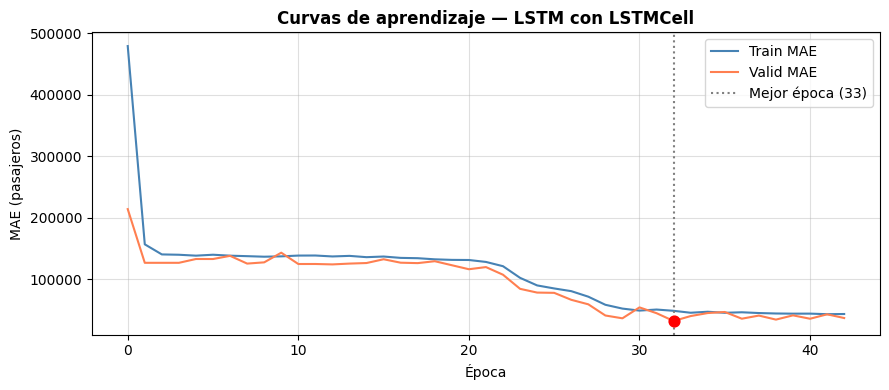

Mejor Valid MAE: 31,953 pasajeros (época 33)


In [8]:
plot_learning_curves(history_lstm_cell, "Curvas de aprendizaje — LSTM con LSTMCell")

---
## <font color="purple">5. Modelo LSTM con el Módulo `nn.LSTM`</font>

Al igual que `nn.RNN`, PyTorch ofrece el módulo `nn.LSTM` que implementa la LSTM completa de forma optimizada. La diferencia principal con `nn.RNN` es que el estado oculto ahora es una **tupla** `(h, c)`:

In [9]:
class LstmModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super().__init__()
        self.lstm   = nn.LSTM(input_size, hidden_size,
                              num_layers=num_layers, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, (h_n, c_n) = self.lstm(X)   # outputs: [batch, seq, hidden]
        return self.output(outputs[:, -1])     # último paso de tiempo


torch.manual_seed(42)
lstm_model = LstmModel(input_size=1, hidden_size=32, output_size=1)
print(lstm_model)
total_params = sum(p.numel() for p in lstm_model.parameters())
print(f"\nParámetros totales: {total_params:,}")

LstmModel(
  (lstm): LSTM(1, 32, batch_first=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
)

Parámetros totales: 4,513


> 📌 **Salidas de `nn.LSTM`**
>
> El módulo retorna **tres objetos**:
> - **`outputs`**: estados ocultos $\mathbf{h}$ en **cada** paso de tiempo. Forma: `[batch, seq_len, hidden_size]`.
> - **`h_n`**: estado oculto del **último** paso de tiempo, para cada capa. Forma: `[num_layers, batch, hidden_size]`.
> - **`c_n`**: estado de celda del **último** paso de tiempo, para cada capa. Forma: `[num_layers, batch, hidden_size]`.
>
> Para el pronóstico usamos `outputs[:, -1]`, que corresponde al último estado oculto.

In [10]:
print("=== Entrenando nn.LSTM ===")
history_lstm = train_model(
    lstm_model, train_loader, valid_loader,
    n_epochs=50, patience=10, model_name="nn.LSTM"
)

=== Entrenando nn.LSTM ===
Época   1/50 | Train MAE: 479,006 | Valid MAE: 213,888 ✓
Época   2/50 | Train MAE: 156,604 | Valid MAE: 126,540 ✓
Época   3/50 | Train MAE: 140,196 | Valid MAE: 126,539 ✓
Época   4/50 | Train MAE: 139,651 | Valid MAE: 126,535 ✓
Época   5/50 | Train MAE: 138,174 | Valid MAE: 132,743
Época   6/50 | Train MAE: 139,693 | Valid MAE: 132,714
Época   7/50 | Train MAE: 138,151 | Valid MAE: 137,875
Época   8/50 | Train MAE: 137,359 | Valid MAE: 125,288 ✓
Época   9/50 | Train MAE: 136,474 | Valid MAE: 127,294
Época  10/50 | Train MAE: 137,048 | Valid MAE: 143,005
Época  11/50 | Train MAE: 138,315 | Valid MAE: 124,591 ✓
Época  12/50 | Train MAE: 138,424 | Valid MAE: 124,623
Época  13/50 | Train MAE: 136,894 | Valid MAE: 123,952 ✓
Época  14/50 | Train MAE: 137,824 | Valid MAE: 125,276
Época  15/50 | Train MAE: 135,724 | Valid MAE: 126,193
Época  16/50 | Train MAE: 136,766 | Valid MAE: 132,333
Época  17/50 | Train MAE: 134,561 | Valid MAE: 126,729
Época  18/50 | Train MAE

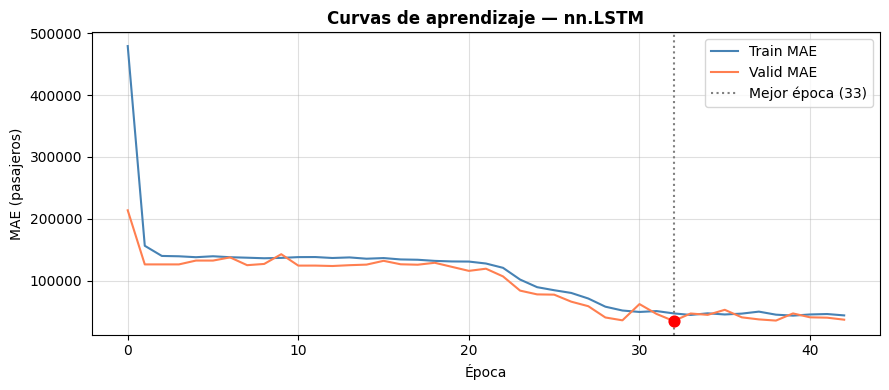

Mejor Valid MAE: 35,209 pasajeros (época 33)


In [11]:
plot_learning_curves(history_lstm, "Curvas de aprendizaje — nn.LSTM")

---
### <font color="blue">**Actividad 1** Comparación LSTMCell vs nn.LSTM</font>

<font color="green">
Ejecuta la celda siguiente para comparar los tiempos de ejecución y responde:

1. ¿Qué diferencias observas en los tiempos de ejecución entre `LstmCellModel` y `LstmModel`? ¿A qué se deben?
2. Ambos modelos deberían alcanzar resultados similares (misma arquitectura). ¿Son exactamente iguales? ¿Por qué podría haber pequeñas diferencias?
3. ¿Cuándo convendría usar `nn.LSTMCell` en lugar de `nn.LSTM`?
</font>

In [12]:
criterion = nn.L1Loss()

for name, model in [("LSTMCell (manual)", lstm_cell_model), ("nn.LSTM", lstm_model)]:
    model_copy = model.to(device)
    model_copy.eval()
    t0 = time.time()
    with torch.no_grad():
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            _ = model_copy(X)
    elapsed = time.time() - t0
    test_mae = evaluate(model_copy, test_loader, criterion, device)
    print(f"{name:22s} → Forward: {elapsed:.4f}s/epoch | Test MAE: {test_mae * 1e6:,.0f} pasajeros")

LSTMCell (manual)      → Forward: 0.1614s/epoch | Test MAE: 175,668 pasajeros
nn.LSTM                → Forward: 0.0886s/epoch | Test MAE: 180,910 pasajeros


**Escribe tus respuestas aquí:**

1. ...
2. ...
3. ...

<details>
<summary>👉 Clic para ver respuesta orientativa</summary>

**1.** `nn.LSTM` es significativamente más rápido porque su bucle temporal está implementado en C++/CUDA, mientras que `LstmCellModel` ejecuta el bucle en Python introduciendo overhead por cada iteración.

**2.** Los resultados son muy similares pero pueden diferir levemente por: diferencias en optimizaciones numéricas internas de cuDNN vs implementación Python, y potencialmente diferente orden de operaciones de punto flotante.

**3.** `nn.LSTMCell` es útil cuando se necesita: (a) aplicar dropout o layer normalization en **cada paso de tiempo**, (b) implementar arquitecturas no estándar como LSTMs con atención, (c) acceder al estado intermedio en cada paso para procesamiento personalizado.
</details>

---
## <font color="purple">6. Modelo GRU Implementado con `nn.GRUCell`</font>

Ahora implementamos la GRU paso a paso con `nn.GRUCell`. Observa la principal diferencia con la LSTM: la GRU **solo tiene un vector de estado** (no hay celda de largo plazo separada), lo que la hace más simple:

In [13]:
class GruCellModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.memory_cell = nn.GRUCell(input_size, hidden_size)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        batch_size, window_length, dimensionality = X.shape
        X_time_first = X.transpose(0, 1)  # [window_length, batch, input_size]

        # La GRU solo tiene UN estado oculto (no hay estado de celda)
        H = torch.zeros(batch_size, self.hidden_size, device=X.device)

        for X_t in X_time_first:
            H = self.memory_cell(X_t, H)

        return self.output(H)


torch.manual_seed(42)
gru_cell_model = GruCellModel(input_size=1, hidden_size=32, output_size=1)
print(gru_cell_model)
total_params = sum(p.numel() for p in gru_cell_model.parameters())
print(f"\nParámetros totales: {total_params:,}")

GruCellModel(
  (memory_cell): GRUCell(1, 32)
  (output): Linear(in_features=32, out_features=1, bias=True)
)

Parámetros totales: 3,393


---
### <font color="blue">**Actividad 2.** Diferencias entre LSTM y GRU a nivel de implementación</font>

<font color="green">
Compara el código de `LstmCellModel` y `GruCellModel` y responde:

1. ¿Qué diferencias concretas de código observas entre ambas implementaciones?
2. Calcula manualmente el número de parámetros del `nn.GRUCell` con `input_size=1` y `hidden_size=32`. Recuerda que la GRU tiene 3 puertas (update, reset, y candidato). ¿Es menor que la LSTM?
</font>

**Escribe tus respuestas aquí:**

1. ...
2. ...

<details>
<summary>👉 Clic para ver respuesta</summary>

**1.** Diferencias: (a) La LSTM inicializa y retorna la tupla `(H, C)`, la GRU solo `H`. (b) `nn.LSTMCell` retorna `(H, C)`, mientras `nn.GRUCell` retorna solo `H`. (c) La llamada `self.memory_cell(X_t, (H, C))` vs `self.memory_cell(X_t, H)`.

**2.** GRU: 3 puertas × (W_xh: `1×32` + W_hh: `32×32` + bias_ih: `32` + bias_hh: `32`) = 3 × 1,120 = **3,360 parámetros**. La GRU tiene 3/4 los parámetros de la LSTM (25% menos).

</details>

In [14]:
print("=== Entrenando GRU con GRUCell ===")
history_gru_cell = train_model(
    gru_cell_model, train_loader, valid_loader,
    n_epochs=50, patience=10, model_name="GRUCell"
)

=== Entrenando GRU con GRUCell ===
Época   1/50 | Train MAE: 383,349 | Valid MAE: 148,451 ✓
Época   2/50 | Train MAE: 151,533 | Valid MAE: 122,550 ✓
Época   3/50 | Train MAE: 135,028 | Valid MAE: 120,752 ✓
Época   4/50 | Train MAE: 132,957 | Valid MAE: 121,348
Época   5/50 | Train MAE: 132,718 | Valid MAE: 129,679
Época   6/50 | Train MAE: 131,382 | Valid MAE: 118,746 ✓
Época   7/50 | Train MAE: 128,575 | Valid MAE: 124,290
Época   8/50 | Train MAE: 128,461 | Valid MAE: 115,987 ✓
Época   9/50 | Train MAE: 127,242 | Valid MAE: 129,608
Época  10/50 | Train MAE: 130,932 | Valid MAE: 136,132
Época  11/50 | Train MAE: 128,491 | Valid MAE: 126,010
Época  12/50 | Train MAE: 124,609 | Valid MAE: 114,701 ✓
Época  13/50 | Train MAE: 125,818 | Valid MAE: 118,253
Época  14/50 | Train MAE: 124,952 | Valid MAE: 114,550 ✓
Época  15/50 | Train MAE: 124,880 | Valid MAE: 113,979 ✓
Época  16/50 | Train MAE: 124,599 | Valid MAE: 115,038
Época  17/50 | Train MAE: 123,942 | Valid MAE: 115,881
Época  18/50 |

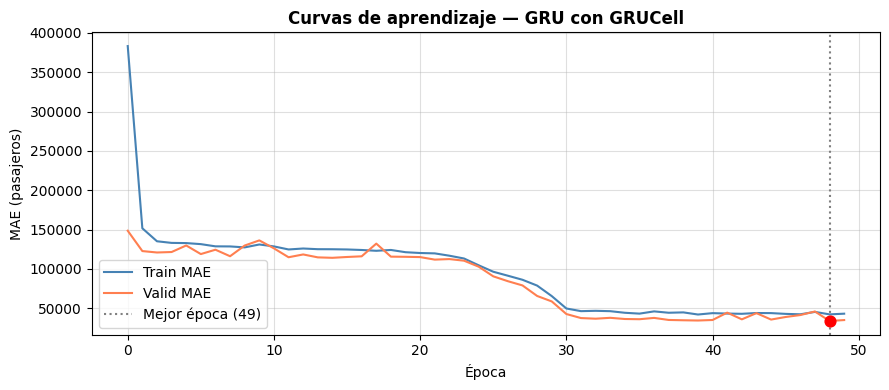

Mejor Valid MAE: 33,623 pasajeros (época 49)


In [15]:
plot_learning_curves(history_gru_cell, "Curvas de aprendizaje — GRU con GRUCell")

---
## <font color="purple">7. Modelo GRU con el Módulo `nn.GRU`</font>

Implementamos la versión optimizada con `nn.GRU`. La interfaz es prácticamente idéntica a `nn.LSTM`, pero retorna un solo tensor de estado oculto en lugar de una tupla:

In [16]:
class GruModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super().__init__()
        self.gru    = nn.GRU(input_size, hidden_size,
                             num_layers=num_layers, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, h_n = self.gru(X)           # outputs: [batch, seq, hidden]
        return self.output(outputs[:, -1])    # último paso de tiempo


torch.manual_seed(42)
gru_model = GruModel(input_size=1, hidden_size=32, output_size=1)
print(gru_model)
total_params = sum(p.numel() for p in gru_model.parameters())
print(f"\nParámetros totales: {total_params:,}")

GruModel(
  (gru): GRU(1, 32, batch_first=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
)

Parámetros totales: 3,393


In [17]:
print("=== Entrenando nn.GRU ===")
history_gru = train_model(
    gru_model, train_loader, valid_loader,
    n_epochs=50, patience=10, model_name="nn.GRU"
)

=== Entrenando nn.GRU ===
Época   1/50 | Train MAE: 383,349 | Valid MAE: 148,451 ✓
Época   2/50 | Train MAE: 151,533 | Valid MAE: 122,550 ✓
Época   3/50 | Train MAE: 135,028 | Valid MAE: 120,752 ✓
Época   4/50 | Train MAE: 132,957 | Valid MAE: 121,348
Época   5/50 | Train MAE: 132,718 | Valid MAE: 129,679
Época   6/50 | Train MAE: 131,382 | Valid MAE: 118,746 ✓
Época   7/50 | Train MAE: 128,575 | Valid MAE: 124,290
Época   8/50 | Train MAE: 128,461 | Valid MAE: 115,987 ✓
Época   9/50 | Train MAE: 127,242 | Valid MAE: 129,608
Época  10/50 | Train MAE: 130,932 | Valid MAE: 136,132
Época  11/50 | Train MAE: 128,491 | Valid MAE: 126,010
Época  12/50 | Train MAE: 124,609 | Valid MAE: 114,701 ✓
Época  13/50 | Train MAE: 125,818 | Valid MAE: 118,253
Época  14/50 | Train MAE: 124,952 | Valid MAE: 114,550 ✓
Época  15/50 | Train MAE: 124,880 | Valid MAE: 113,979 ✓
Época  16/50 | Train MAE: 124,599 | Valid MAE: 115,038
Época  17/50 | Train MAE: 123,942 | Valid MAE: 115,881
Época  18/50 | Train MA

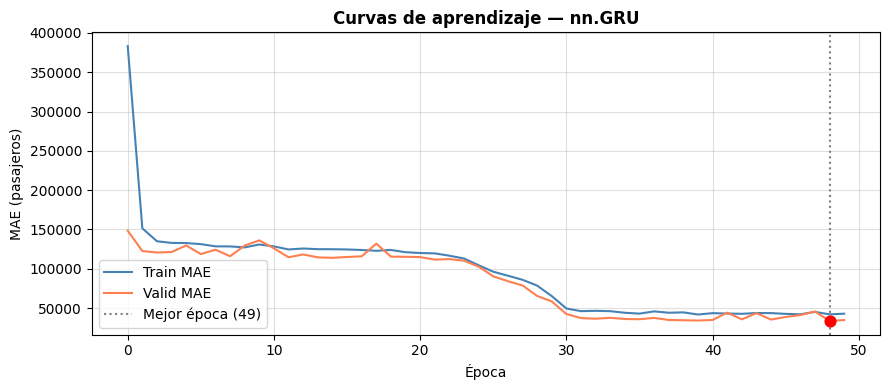

Mejor Valid MAE: 33,621 pasajeros (época 49)


In [18]:
plot_learning_curves(history_gru, "Curvas de aprendizaje — nn.GRU")

---
## <font color="purple">8. LSTM Apilada (Stacked LSTM)</font>

Una técnica común para aumentar la capacidad del modelo es **apilar múltiples capas recurrentes**. En `nn.LSTM`, esto se controla con el parámetro `num_layers`. La salida de cada capa se convierte en la entrada de la siguiente:

In [19]:
torch.manual_seed(42)
stacked_lstm_model = LstmModel(input_size=1, hidden_size=32, output_size=1, num_layers=2)
print(stacked_lstm_model)
total_params = sum(p.numel() for p in stacked_lstm_model.parameters())
print(f"\nParámetros totales: {total_params:,}")

LstmModel(
  (lstm): LSTM(1, 32, num_layers=2, batch_first=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
)

Parámetros totales: 12,961


---
### <font color="blue">**Actividad 3.** LSTM apilada</font>

<font color="green">
Antes de entrenar el modelo apilado, responde:

1. ¿Por qué apilar capas puede ayudar al modelo a capturar patrones más complejos?
2. ¿Qué riesgo introduce añadir más capas en el entrenamiento?
</font>

In [20]:
print("=== Entrenando LSTM apilada (2 capas) ===")
history_stacked = train_model(
    stacked_lstm_model, train_loader, valid_loader,
    n_epochs=50, patience=10, model_name="LSTM-2layers"
)

=== Entrenando LSTM apilada (2 capas) ===
Época   1/50 | Train MAE: 334,872 | Valid MAE: 130,919 ✓
Época   2/50 | Train MAE: 144,619 | Valid MAE: 143,481
Época   3/50 | Train MAE: 140,916 | Valid MAE: 139,085
Época   4/50 | Train MAE: 138,767 | Valid MAE: 124,364 ✓
Época   5/50 | Train MAE: 139,796 | Valid MAE: 127,853
Época   6/50 | Train MAE: 137,921 | Valid MAE: 127,552
Época   7/50 | Train MAE: 138,457 | Valid MAE: 124,740
Época   8/50 | Train MAE: 139,116 | Valid MAE: 123,711 ✓
Época   9/50 | Train MAE: 138,092 | Valid MAE: 123,619 ✓
Época  10/50 | Train MAE: 138,235 | Valid MAE: 123,353 ✓
Época  11/50 | Train MAE: 136,998 | Valid MAE: 123,730
Época  12/50 | Train MAE: 137,353 | Valid MAE: 134,622
Época  13/50 | Train MAE: 133,888 | Valid MAE: 123,855
Época  14/50 | Train MAE: 127,879 | Valid MAE: 113,066 ✓
Época  15/50 | Train MAE: 102,015 | Valid MAE: 80,648 ✓
Época  16/50 | Train MAE: 76,669 | Valid MAE: 51,897 ✓
Época  17/50 | Train MAE: 58,598 | Valid MAE: 51,875 ✓
Época  18/

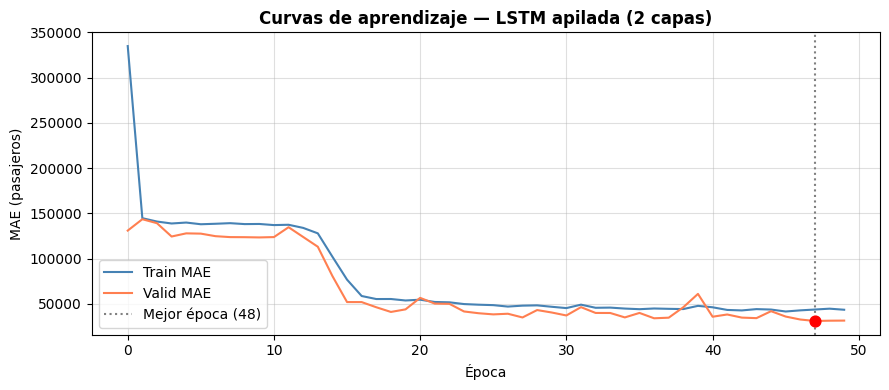

Mejor Valid MAE: 30,999 pasajeros (época 48)


In [21]:
plot_learning_curves(history_stacked, "Curvas de aprendizaje — LSTM apilada (2 capas)")

**Escribe tus respuestas aquí:**

1. ...
2. ...


<details>
<summary>👉 Clic para ver respuesta orientativa</summary>

**1.** Las capas apiladas aprenden representaciones en niveles de abstracción creciente. La primera capa extrae patrones locales (día de la semana), la segunda puede capturar patrones de más alto nivel (tendencias mensuales).

**2.** Mayor riesgo de sobreajuste con datasets pequeños. También puede presentar gradientes más inestables al tener más capas profundas en tiempo y en profundidad.
</details>

---
## <font color="purple">9. Comparación Final de Modelos</font>

Evaluamos todos los modelos en el conjunto de prueba y generamos una comparación visual completa.

In [22]:
criterion = nn.L1Loss()

models = [
    ("LSTMCell (manual)",  lstm_cell_model),
    ("nn.LSTM",            lstm_model),
    ("GRUCell (manual)",   gru_cell_model),
    ("nn.GRU",             gru_model),
    ("LSTM apilada",       stacked_lstm_model),
]

print(f"{'Modelo':<22} {'Parámetros':>12} {'Test MAE (pasajeros)':>22}")
print("-" * 60)

results = {}
for name, model in models:
    test_mae = evaluate(model, test_loader, criterion, device)
    n_params = sum(p.numel() for p in model.parameters())
    results[name] = test_mae
    print(f"{name:<22} {n_params:>12,} {test_mae * 1e6:>22,.0f}")

Modelo                   Parámetros   Test MAE (pasajeros)
------------------------------------------------------------
LSTMCell (manual)             4,513                175,668
nn.LSTM                       4,513                180,910
GRUCell (manual)              3,393                123,737
nn.GRU                        3,393                123,734
LSTM apilada                 12,961                155,842


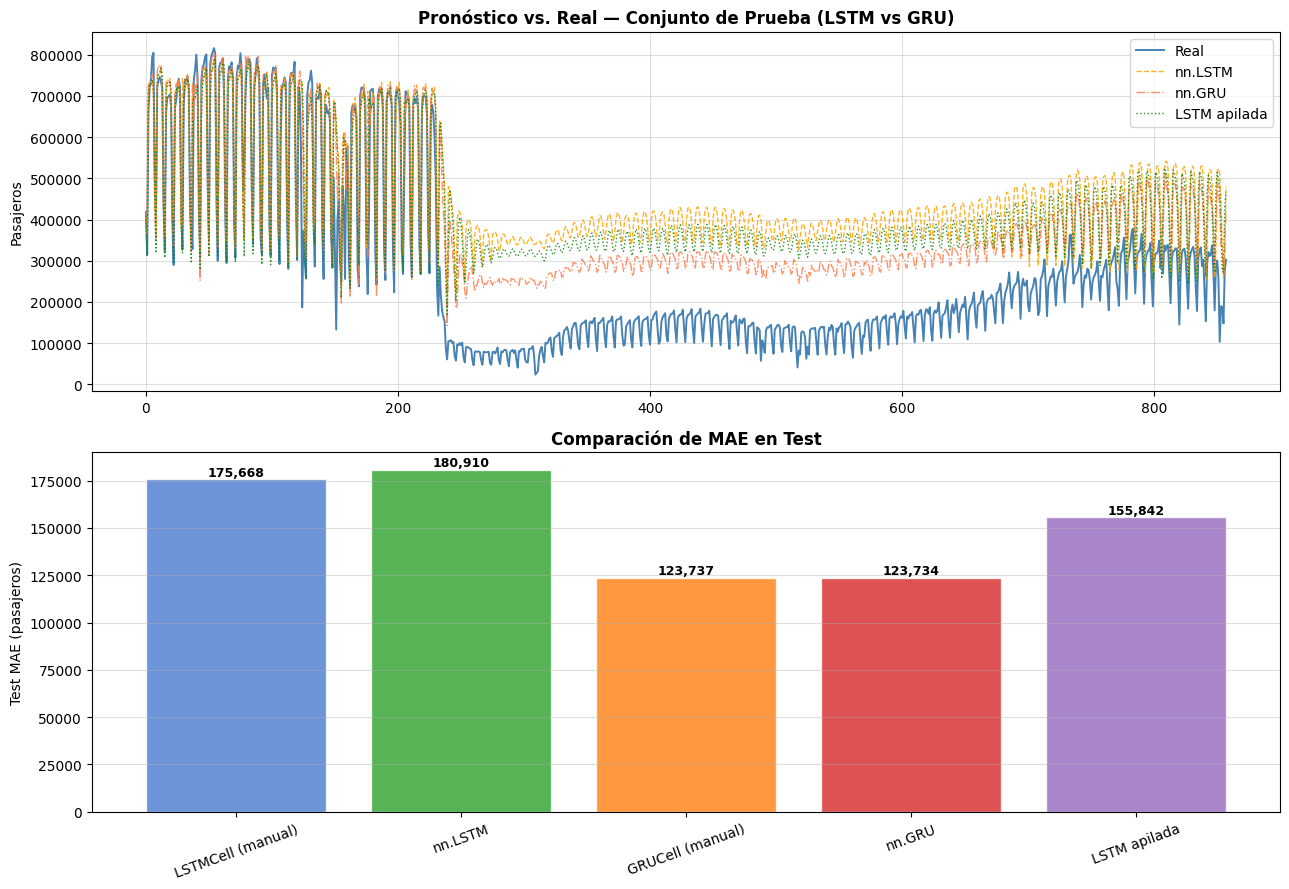

In [23]:
# Obtenemos predicciones de los mejores modelos (nn.LSTM y nn.GRU)
preds_lstm, targets_test = get_predictions(lstm_model,    test_loader, device)
preds_gru,  _            = get_predictions(gru_model,     test_loader, device)
preds_stk,  _            = get_predictions(stacked_lstm_model, test_loader, device)

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# Panel superior: pronósticos vs real
axes[0].plot(targets_test * 1e6,  label="Real",         color="steelblue",  linewidth=1.4)
axes[0].plot(preds_lstm   * 1e6,  label="nn.LSTM",      color="orange",
             linestyle="--", linewidth=1.0, alpha=0.85)
axes[0].plot(preds_gru    * 1e6,  label="nn.GRU",       color="coral",
             linestyle="-.", linewidth=1.0, alpha=0.85)
axes[0].plot(preds_stk    * 1e6,  label="LSTM apilada", color="green",
             linestyle=":",  linewidth=1.0, alpha=0.85)
axes[0].set_ylabel("Pasajeros")
axes[0].set_title("Pronóstico vs. Real — Conjunto de Prueba (LSTM vs GRU)", fontweight="bold")
axes[0].legend()
axes[0].grid(alpha=0.4)

# Panel inferior: comparación de MAE en barras
names_bar = list(results.keys())
maes_bar  = [v * 1e6 for v in results.values()]
colors_bar = ["#4878CF", "#2ca02c", "#FF7F0E", "#D62728", "#9467BD"]
bars = axes[1].bar(names_bar, maes_bar, color=colors_bar, alpha=0.8, edgecolor="white")
axes[1].set_ylabel("Test MAE (pasajeros)")
axes[1].set_title("Comparación de MAE en Test", fontweight="bold")
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(axis="y", alpha=0.4)
for bar, mae in zip(bars, maes_bar):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f"{mae:,.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

---
### <font color="blue">**Actividad 4.** Análisis de resultados</font>

<font color="green">
Observa los resultados de la comparación y responde:

1. ¿Qué modelo obtuvo el mejor Test MAE? ¿Coincide con tus expectativas? ¿Por qué?
2. Compara el desempeño de `nn.LSTM` vs `nn.GRU`. ¿La diferencia en parámetros se justifica por la diferencia en rendimiento?
3. ¿La LSTM apilada de 2 capas mejoró respecto a la de 1 capa? Si no mejoró, ¿qué podría explicarlo dado el tamaño del dataset?
4. ¿En qué períodos del año (observando la gráfica) los modelos cometen más errores? ¿Por qué crees que ocurre esto?
</font>

**Escribe tus respuestas aquí:**

1. ...
2. ...
3. ...
4. ...

<details>
<summary>👉 Clic para ver puntos clave</summary>

**1.** En datasets de tamaño moderado, la GRU suele competir de cerca con la LSTM o incluso superarla, ya que tiene menos parámetros y puede generalizar mejor con menos datos.

**2.** Con `hidden_size=32` la diferencia de parámetros entre GRU (3,360) y LSTM (4,480 + output) es de ~25%. Si la GRU obtiene resultados similares, es la opción más eficiente.

**3.** La LSTM apilada puede no mejorar por sobreajuste: el dataset de entrenamiento (2016–2018) tiene ~1,100 puntos, lo que es relativamente pequeño para una red más profunda.

**4.** Los mayores errores suelen ocurrir en feriados y eventos especiales (Navidad, Año Nuevo, etc.) ya que representan anomalías que el modelo no ha visto suficientemente en entrenamiento. Por ejemplo, durante el 2020 la cuarentena obligó a las personas a quedarse en sus casas.
</details>

---
## Referencias

- Géron, A. (2023). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3ª ed.). O'Reilly Media. Capítulo 15.
- Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. *Neural Computation*, 9(8), 1735–1780.
- Cho, K., et al. (2014). Learning phrase representations using RNN encoder-decoder for statistical machine translation. *arXiv:1406.1078*.
- PyTorch Documentation. `torch.nn.LSTM`: https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html
- PyTorch Documentation. `torch.nn.GRU`: https://pytorch.org/docs/stable/generated/torch.nn.GRU.html
- Chicago Transit Authority (CTA). *Ridership Dataset*: https://data.cityofchicago.org/